## Investigation of the reliability of T1w images

In [1]:
import re
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from bids import BIDSLayout
from nipype.interfaces.ants import ApplyTransforms

data_path = Path("/data/derivatives/hcph-smriprep-reliability")
layout = BIDSLayout(data_path / "smriprep", validate=False)

## Preprocessing

Smriprep does not directly output the individual T1w image that have been corrected for intensity non-uniformity (INU), it only outputs the preprocessed T1w combining all T1w from the same subject, which is the reference T1w image for alignement. To get access to the bias-field corrected individual T1w, we copied them from smriprep work directory into `inu_corrected_individual_T1w`. Specifially, they were stored in `$WORKDIR/smriprep_wf/single_subject_001_wf/anat_preproc_wf/anat_fit_wf/anat_template_wf/n4_correct/mapflow/_n4_correct*/*.nii.gz`. Let's first load those INU-corrected T1w images.

In [2]:
# Locate the inu-corrected individual T1w images
t1w_files = list((data_path / "inu_corrected_individual_T1w").glob("*_corrected.nii.gz"))
t1w_df = pd.DataFrame({"t1w_file": t1w_files})
t1w_df = t1w_df.assign(session=t1w_df["t1w_file"].astype(str).str.extract(r'ses-(\d+)')[0])

# Locate the reference T1w image
ref_t1w = layout.get(desc="preproc", suffix="T1w", extension=".nii.gz")[0]
ref_t1w_img = nib.load(ref_t1w)

assert len(t1w_files) == 36

print(t1w_df.head())

                                            t1w_file session
0  /data/derivatives/hcph-smriprep-reliability/in...     009
1  /data/derivatives/hcph-smriprep-reliability/in...     021
2  /data/derivatives/hcph-smriprep-reliability/in...     025
3  /data/derivatives/hcph-smriprep-reliability/in...     001
4  /data/derivatives/hcph-smriprep-reliability/in...     005


So that the voxel are aligned across sessions, we will use the transformation computed by smriprep to register the T1w images into a common space (the space of global preprocessed T1w image output by smriprep).

In [3]:
# Locate the transformation to register images to the reference T1w
transform_files = layout.get(suffix='xfm', to='T1w', extension='txt', return_type='file')
# 'from' entity in layout.get get misinterpreted
transform_files = [f for f in transform_files if 'from-orig' in f]
transform_df = pd.DataFrame({"transform_file": transform_files})
transform_df = transform_df.assign(session=transform_df["transform_file"].astype(str).str.extract(r'ses-(\d+)')[0])

t1w_df = pd.merge(t1w_df, transform_df, on="session", how="inner")
print(t1w_df["t1w_file"])

0     /data/derivatives/hcph-smriprep-reliability/in...
1     /data/derivatives/hcph-smriprep-reliability/in...
2     /data/derivatives/hcph-smriprep-reliability/in...
3     /data/derivatives/hcph-smriprep-reliability/in...
4     /data/derivatives/hcph-smriprep-reliability/in...
5     /data/derivatives/hcph-smriprep-reliability/in...
6     /data/derivatives/hcph-smriprep-reliability/in...
7     /data/derivatives/hcph-smriprep-reliability/in...
8     /data/derivatives/hcph-smriprep-reliability/in...
9     /data/derivatives/hcph-smriprep-reliability/in...
10    /data/derivatives/hcph-smriprep-reliability/in...
11    /data/derivatives/hcph-smriprep-reliability/in...
12    /data/derivatives/hcph-smriprep-reliability/in...
13    /data/derivatives/hcph-smriprep-reliability/in...
14    /data/derivatives/hcph-smriprep-reliability/in...
15    /data/derivatives/hcph-smriprep-reliability/in...
16    /data/derivatives/hcph-smriprep-reliability/in...
17    /data/derivatives/hcph-smriprep-reliabilit

In [4]:
# Apply the transformation to each T1w image
for index, row in t1w_df.iterrows():  
    # Set up the ApplyTransforms interface
    output_file = str(row['t1w_file']).replace(".nii.gz", "_aligned.nii.gz")
    if not Path(output_file).exists():
        at = ApplyTransforms()
        at.inputs.input_image = str(row['t1w_file'])
        at.inputs.transforms = str(row['transform_file'])
        at.inputs.reference_image = ref_t1w
        at.inputs.output_image = str(row['t1w_file']).replace(".nii.gz", "_aligned.nii.gz")
        
        # Run the transformation
        result = at.run()
        print(f"Transformation applied for session {row['session']}, output saved to {output_file}")

Quality Control: Now that we applied the transformation and wrote down the resulting image, verify using brain imaging visualization tool that the images are well aligned.

Once quality control is done, we can extract the WM, GM and CSF voxels from each T1w image using the segmentation probability maps they were computed by smriprep.

In [ ]:
# Load segmentation files
csf_seg_file = layout.get(suffix='probseg', space=None, label='CSF', extension='nii.gz', return_type='file')
csf_seg = nib.load(csf_seg_file[0]).get_fdata()
gm_seg_file = layout.get(suffix='probseg', space=None, label='GM', extension='nii.gz', return_type='file')
gm_seg = nib.load(gm_seg_file[0]).get_fdata()
wm_seg_file = layout.get(suffix='probseg', space=None, label='WM', extension='nii.gz', return_type='file')
wm_seg = nib.load(wm_seg_file[0]).get_fdata()

# Binarize the probability maps
thresh = 0.6
wm_seg = wm_seg > thresh
gm_seg = gm_seg > thresh
csf_seg = csf_seg > thresh

assert np.array_equal(np.unique(wm_seg), [0, 1]), "wm_seg is not binary"
assert np.array_equal(np.unique(gm_seg), [0, 1]), "gm_seg is not binary"
assert np.array_equal(np.unique(csf_seg), [0, 1]), "csf_seg is not binary"

# Locate the aligned T1w images
t1w_aligned_files = list((data_path / "inu_corrected_individual_T1w").glob("*_aligned.nii.gz"))
assert len(t1w_aligned_files) == 36

# Apply the masks to the aligned T1w images
t1w_aligned = []
t1w_wm = []
t1w_gm = []
t1w_csf = []
for file in t1w_aligned_files:
    img = nib.load(file)
    t1w = img.get_fdata()
    t1w_aligned.append(t1w)

    assert t1w.shape == wm_seg.shape
    assert t1w.shape == gm_seg.shape
    assert t1w.shape == csf_seg.shape

    t1w_wm.append(np.multiply(t1w, wm_seg))
    t1w_gm.append(np.multiply(t1w, gm_seg))
    t1w_csf.append(np.multiply(t1w, csf_seg))

assert len(t1w_aligned) == 36
assert t1w_wm[0].shape == wm_seg.shape

# Convert to numpy arrays
t1w_wm = np.array(t1w_wm)
t1w_gm = np.array(t1w_gm)
t1w_csf = np.array(t1w_csf)
t1w_aligned = np.array(t1w_aligned)

# Save the 4D image containing all the T1w images as a NIfTI file
t1w_4d_img = nib.Nifti1Image(t1w_aligned, ref_t1w_img.affine, ref_t1w_img.header)
output_path = data_path / "t1w_aligned_4d.nii.gz"
nib.save(t1w_4d_img, output_path)
print(f"4D T1w image saved to {output_path}")

In [6]:
# Compute the coefficient of variation to assess reliability
cov_wm = np.std(t1w_wm, axis=0) / np.mean(t1w_wm, axis=0)
cov_gm = np.std(t1w_gm, axis=0) / np.mean(t1w_gm, axis=0)
cov_csf = np.std(t1w_csf, axis=0) / np.mean(t1w_csf, axis=0)

/tmp/ipykernel_252090/279515303.py:2: RuntimeWarning: invalid value encountered in divide
  cov_wm = np.std(t1w_wm, axis=0) / np.mean(t1w_wm, axis=0)
/tmp/ipykernel_252090/279515303.py:3: RuntimeWarning: invalid value encountered in divide
  cov_gm = np.std(t1w_gm, axis=0) / np.mean(t1w_gm, axis=0)
/tmp/ipykernel_252090/279515303.py:4: RuntimeWarning: invalid value encountered in divide
  cov_csf = np.std(t1w_csf, axis=0) / np.mean(t1w_csf, axis=0)


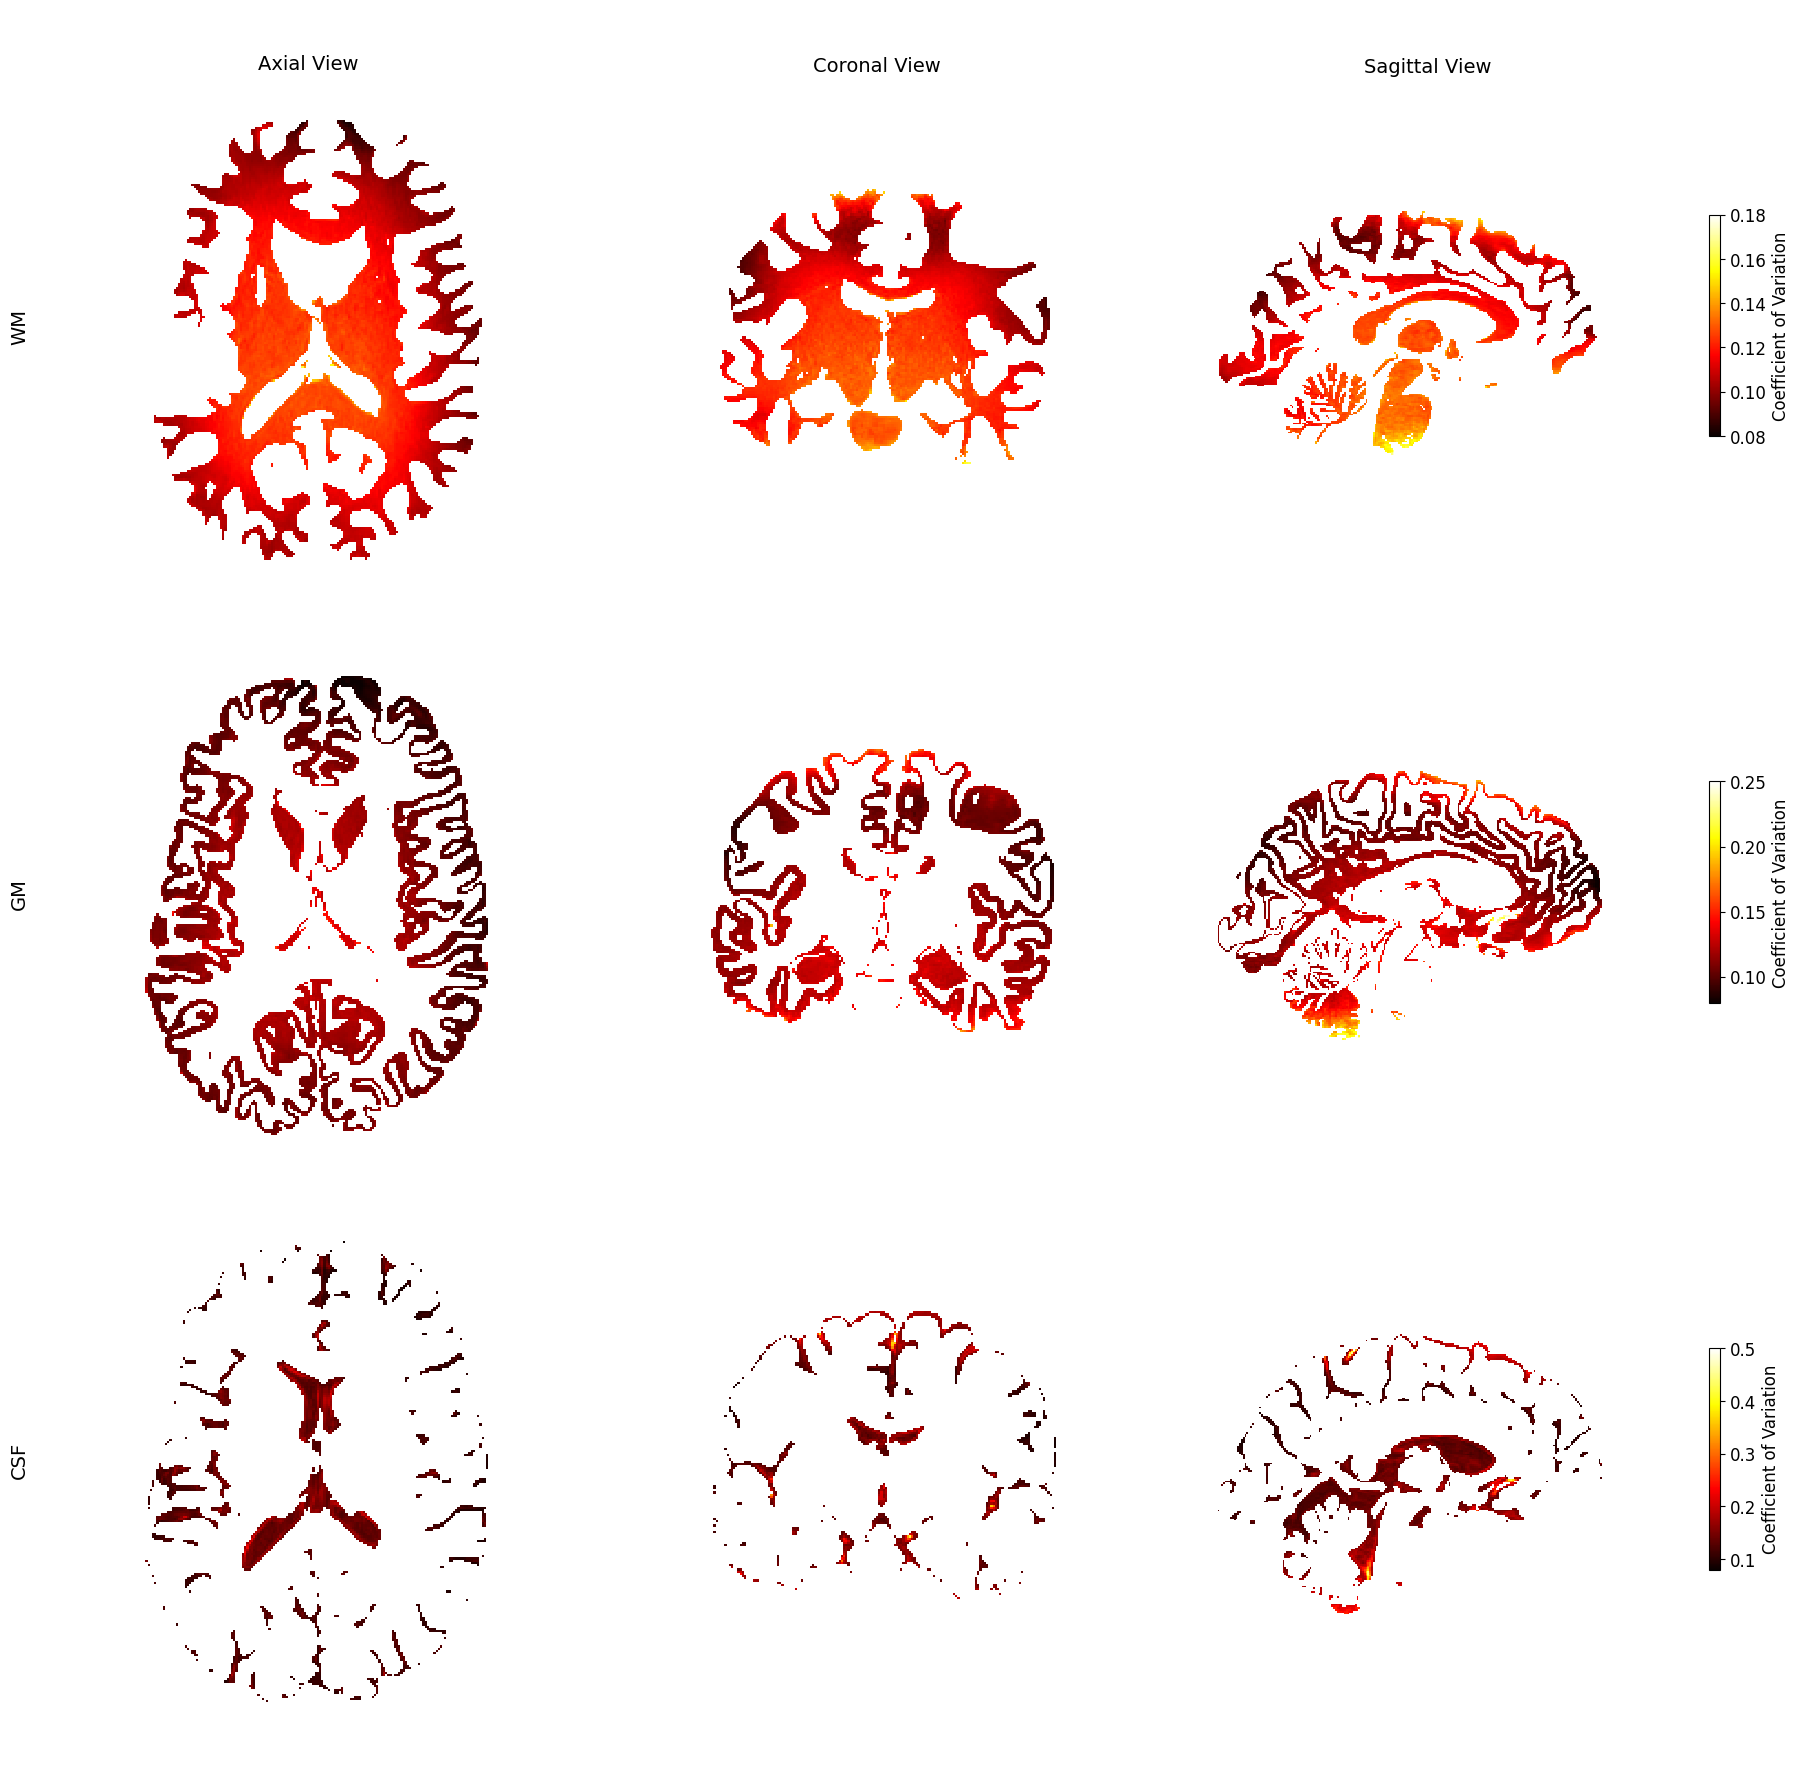

In [64]:
vmax = [0.18, 0.25, 0.5]
y_title = [20, -19, -45]
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
slices = [
    [
        np.rot90(cov[:, :, cov.shape[2] // 2], k=1),
        np.rot90(cov[:, cov.shape[1] // 2, :], k=1),
        np.rot90(cov[cov.shape[0] // 2, :, :], k=1)
    ]
    for cov in [cov_wm, cov_gm, cov_csf]
]
titles = ["Axial View", "Coronal View", "Sagittal View"]
y_labels = ["WM", "GM", "CSF"]

for i, (cov_slices, y_label) in enumerate(zip(slices, y_labels)):
    for j, (slice_, title) in enumerate(zip(cov_slices, titles)):
        ax = axes[i, j]
        im = ax.imshow(slice_, cmap="hot", interpolation="nearest", vmax=vmax[i], vmin=0.08)
        ax.text(slice_.shape[1] // 2, y_title[j], title if i == 0 else "", 
            fontsize=14, horizontalalignment='center', verticalalignment='top')
        ax.text(-10, slice_.shape[0] // 2, y_label if j == 0 else "", 
            fontsize=14, rotation=90, verticalalignment='center')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        if j == 2:
            cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.04, label="Coefficient of Variation")
            cbar.ax.tick_params(labelsize=12, labelrotation=0)
            cbar.set_label("Coefficient of Variation", fontsize=12)

plt.tight_layout(h_pad=-5)  # Reduce vertical space between subplots
plt.show()

    # Save the coefficient of variation as a NIfTI file
    #cov_img = nib.Nifti1Image(cov, ref_t1w_img.affine, ref_t1w_img.header)

    #from nilearn.plotting import plot_anat
    #plot_anat(cov_img, cmap="hot", vmax=vmax[i], vmin=0.08, colorbar=True, cut_coords=(0, 0, 0), title="Coefficient of Variation", display_mode="ortho")